### Numpy

In [1]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np


In [3]:
# 기본 리스트
%%timeit
result = []
for i in range(10000):
    result.append(i)

276 μs ± 2.31 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [5]:
%%timeit
# 리스트 컴프리헨션

result = [i for i in range(10000)]

197 μs ± 463 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [6]:
%%timeit
# 내장 함수
result = list(range(10000))

77 μs ± 434 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [ ]:

%%timeit
arr = np.array(10000)

202 ns ± 0.445 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [3]:
alist = [1,2,3,4,5]
result = []

for i in alist:
    result.append(i * 2)
    
result

[2, 4, 6, 8, 10]

In [13]:
data = np.array([1,2,3,4,5])
data * 2

array([ 2,  4,  6,  8, 10])

In [17]:
a = np.array([1,2,3])
b = np.array([10,20,30])

(a == 2) & (b > 10)

array([False,  True, False])

In [29]:
a = np.array([[0,1,2],[3,4,5]])

a[0,0]

np.int64(0)

In [36]:
a = np.array([[0,1,2,3],[4,5,6,7]])

print(a[:2,:2])

[[0 1]
 [4 5]]


In [44]:
a = np.array([0,1,2,3,4,5,6,7,8,9])
# idx = np.array([1,0,1,0,1,0,1,0,1,0])
idx = np.array(a % 2 == 0)
a[idx]

array([0, 2, 4, 6, 8])

In [61]:
a = np.array([[1,2,3,4],[5,6,7,8],[9,10,11,12]])
a[[2,0,1],:]

array([[ 9, 10, 11, 12],
       [ 1,  2,  3,  4],
       [ 5,  6,  7,  8]])

In [90]:
x = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])
a = x[x%3==0]
b = x[x%4 == 1]
c = x[(x%3 == 0) & (x%4 == 1)]
c
# x[x%4==1]

array([9])

### 판다스

In [97]:
import pandas as pd

In [96]:
df = pd.DataFrame{
    'Division': ['부산광역시','전라남도','강원도'],
    'Code': ['051','061','033'],
    'Population' : [3495315, 1728600, 1547280]
}

df

SyntaxError: invalid syntax (2850858515.py, line 1)

In [103]:
df = pd.read_csv('data\\heroes.csv')

df

,이름,나이,직업,국적,키,재산
0,아이언맨,58,CEO,미국,174,11500000000
1,토르,45,신,아스가르드,190,NaN
2,스파이더맨,18,고등학생,미국,177,600
3,원더우먼,27,공주,데미스키라,178,NaN
4,헐크,33,핵물리학자,미국,270,1000000000
5,캡틴마블,25,파일럿,미국,170,340000000
6,블랙위도우,32,스파이,러시아,170,50000000


In [149]:
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
# 1. head(), tail(), sample()
# 2. info()
# 3. describe()

In [115]:
# 국적 컬럼만 선택

df['나이'].nlargest()

0    58
1    45
4    33
6    32
3    27
Name: 나이, dtype: int64

In [118]:
#이름, 직업, 국적

df[['이름','직업','국적']]

,이름,직업,국적
0,아이언맨,CEO,미국
1,토르,신,아스가르드
2,스파이더맨,고등학생,미국
3,원더우먼,공주,데미스키라
4,헐크,핵물리학자,미국
5,캡틴마블,파일럿,미국
6,블랙위도우,스파이,러시아


In [128]:
# 나이가 30세 이상이고 50세 미만인 영웅들 중에서 이름과 직업과 국적
df[(df['나이'] >= 30) & (df['나이'] < 50)][['이름','직업','국적']]

,이름,직업,국적
1,토르,신,아스가르드
4,헐크,핵물리학자,미국
6,블랙위도우,스파이,러시아


In [129]:
df.loc[(df['나이'] >= 30) & (df['나이'] < 50),['이름','직업','국적']]

,이름,직업,국적
1,토르,신,아스가르드
4,헐크,핵물리학자,미국
6,블랙위도우,스파이,러시아


In [140]:
df[df['직업'] == '스파이'][['이름','국적']]

,이름,국적
6,블랙위도우,러시아


In [147]:
df.loc[df(['직업'] == '스파이'),[['이름','직업','국적']]]

TypeError: 'DataFrame' object is not callable

In [176]:
# key 컬럼을 m 단위로 변경

df[df['재산'].isnull()]
df.dropna()

,이름,나이,직업,국적,키,재산
0,아이언맨,58,CEO,미국,1.74,11500000000.00
2,스파이더맨,18,고등학생,미국,1.77,600.00
4,헐크,33,핵물리학자,미국,2.70,1000000000.00
5,캡틴마블,25,파일럿,미국,1.70,340000000.00
6,블랙위도우,32,스파이,러시아,1.70,50000000.00


In [178]:
df['재산'] = df['재산'].fillna(0)

In [180]:
df.groupby('국적')['나이'].mean()

국적
데미스키라   27.00
러시아     32.00
미국      33.50
아스가르드   45.00
Name: 나이, dtype: float64

In [243]:
df = pd.read_csv('data\\천안_아파트_실거래가_201810.csv')
df['거래금액'] = df['거래금액'].str.replace(',', '').astype(int)
result = df.groupby('법정동')['거래금액'].mean()
print(result)
# df.groupby('법정동')['거래금액'].mean()

법정동
백석동   23000.00
불당동   34925.00
쌍용동   17470.00
Name: 거래금액, dtype: float64


### 시각화

In [ ]:
# matplotlib, seaborn

In [189]:
%pip install matplotlib seaborn

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----------------------------- -------- 61.4/80.3 kB 825.8 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 897.7 kB/s eta 0:00:00
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     -------------------------------------- 121.0/121.0 kB 7.4 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/9.3 MB 14.2 MB/s eta 0:00:01
   ---- ----------------------------------- 1.0/9.3 MB 12.5 MB/s eta 0:00:01
   ------ --------------------------------- 1.6/9.3 


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


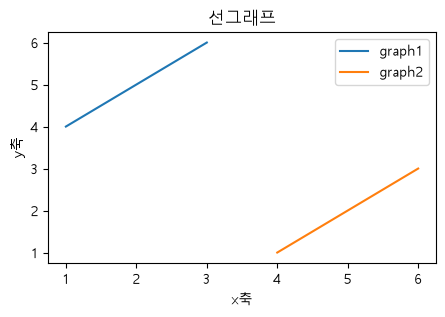

In [197]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,3))
plt.rc('font',family='Malgun Gothic') 
plt.rc('axes',unicode_minus=False)


plt.plot([1,2,3],[4,5,6], label = 'graph1')
plt.plot([4,5,6],[1,2,3], label = 'graph2')# 그래프의 종류와 좌표
plt.legend()
plt.title('선그래프') # 제목달기
plt.xlabel('x축') # x축 이름 달기
plt.ylabel('y축') # y축 이름 달기
plt.show() # 그래프 그리기

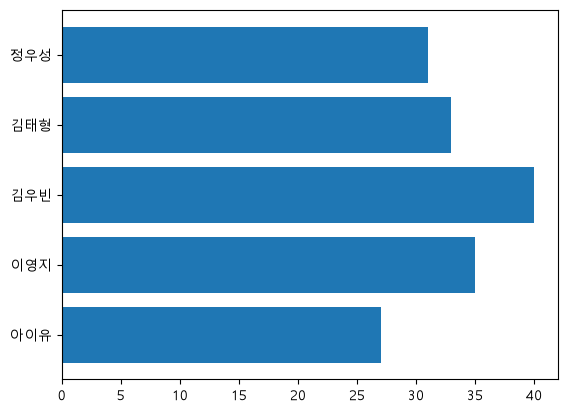

In [219]:
# 막대그래프, 히스토그램, 산점도
df = pd.read_csv('data\\피트니스_회원별_윗몸일으키기_횟수.csv')
x = df['회원ID']
y = df['운동시작전']

plt.barh(x,y)

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

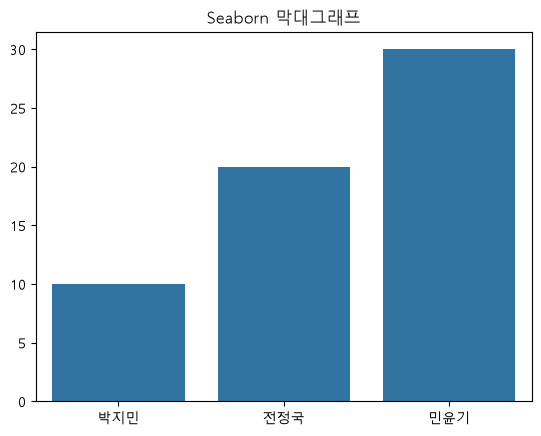

In [220]:
sns.barplot(x=['박지민','전정국','민윤기'], y=[10,20,30])

plt.title('Seaborn 막대그래프')
plt.show

<Axes: xlabel='total_bill', ylabel='tip'>

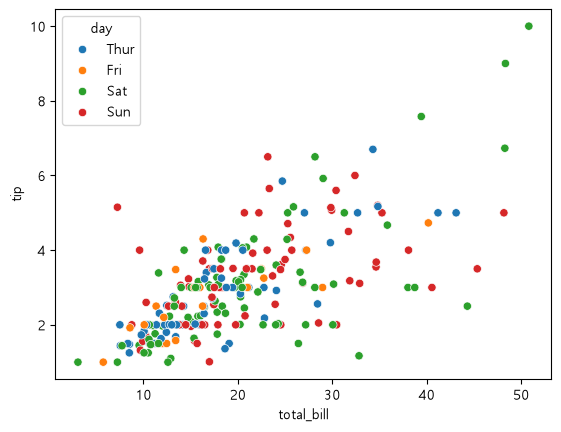

In [236]:
tips = sns.load_dataset('tips')

# sns.barplot(x='day',y='total_bill',data = tips, hue = 'sex')
sns.scatterplot(x='total_bill',y='tip',data = tips, hue = 'day')

<Axes: xlabel='day', ylabel='total_bill'>

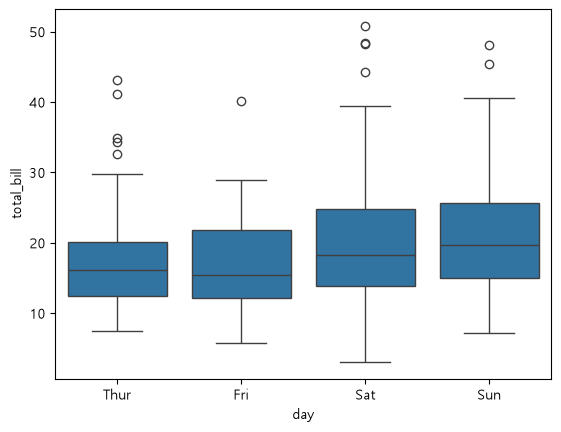

In [237]:
sns.boxplot(data = tips, x = 'day' , y = 'total_bill')

<Axes: >

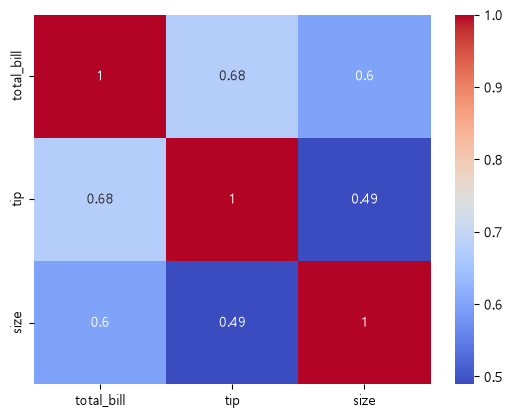

In [242]:
tips_corr = tips.select_dtypes(include = 'number').corr()
sns.heatmap(data = tips_corr,annot = True, cmap = 'coolwarm')

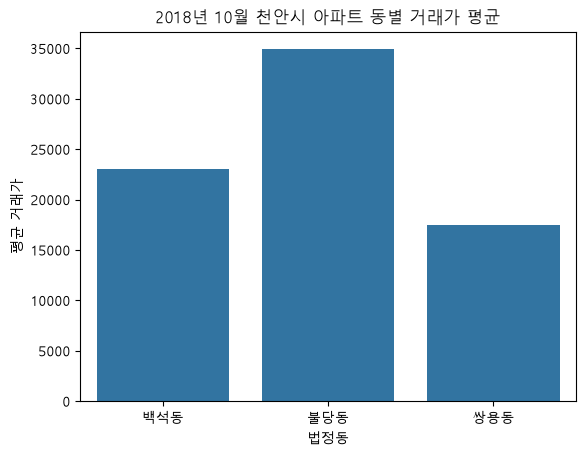

In [280]:
df = pd.read_csv('data\\천안_아파트_실거래가_201810.csv')
df['거래금액'] = df['거래금액'].str.replace(',', '').astype(int)
sns.barplot(df.groupby('법정동')['거래금액'].mean())
plt.xlabel('법정동')
plt.ylabel('평균 거래가')
plt.title('2018년 10월 천안시 아파트 동별 거래가 평균')
plt.show()


# plt.plot([1,2,3],[4,5,6], label = 'graph1')
# plt.plot([4,5,6],[1,2,3], label = 'graph2')# 그래프의 종류와 좌표
# plt.legend()
# plt.title('선그래프') # 제목달기
# plt.xlabel('x축') # x축 이름 달기
# plt.ylabel('y축') # y축 이름 달기
# plt.show() # 그래프 그리기
# plt.title('Seaborn 막대그래프')
# plt.show